In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.stattools import ccf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('Zab_v_bolshikh_gorodakh.xlsx', sheet_name='Лист1')

def clean_data(df):
    df_clean = df.copy()

    df_clean['wd_total'] = pd.to_numeric(df_clean['wd_total'], errors='coerce')
    df_clean['qty_total'] = pd.to_numeric(df_clean['qty_total'], errors='coerce')

    df_clean = df_clean.replace('Э', np.nan)

    df_clean['date'] = pd.to_datetime(
        df_clean['cld_year'].astype(str) + '-W' +
        df_clean['week_number'].astype(str).str.zfill(2) + '-1',
        format='%Y-W%W-%w',
        errors='coerce'
    )

    for city in df_clean['town_name'].unique():
        mask = df_clean['town_name'] == city
        df_clean.loc[mask, 'wd_total'] = df_clean.loc[mask, 'wd_total'].interpolate(
            method='linear',
            limit_direction='both'
        )

    for city in df_clean['town_name'].unique():
        mask = df_clean['town_name'] == city
        median_val = df_clean.loc[mask, 'wd_total'].median()
        df_clean.loc[mask, 'wd_total'] = df_clean.loc[mask, 'wd_total'].fillna(median_val)

    df_clean = df_clean.dropna(subset=['wd_total', 'qty_total'])

    return df_clean

df_clean = clean_data(df)
print(f"Размер данных после очистки: {df_clean.shape}")
print(f"Города в данных: {df_clean['town_name'].unique()}")

Размер данных после очистки: (18953, 7)
Города в данных: ['Екатеринбург' 'Казань' 'Москва' 'Нижний_Новгород' 'Новосибирск' 'Омск'
 'Пермь' 'Ростов-на-Дону' 'Самара' 'Санкт-Петербург' 'Уфа' 'Челябинск']


In [ ]:
def create_panel_data(df):
    panel = df.pivot_table(
        index=['cld_year', 'week_number'],
        columns='town_name',
        values='wd_total'
    )

    panel = panel.fillna(method='ffill').fillna(method='bfill')

    return panel

panel_data = create_panel_data(df_clean)
print(f"Размер панели: {panel_data.shape}")
print(panel_data.head())

Размер панели: (1592, 12)
town_name             Екатеринбург  Казань   Москва  Нижний_Новгород  \
cld_year week_number                                                   
1985     17                    0.0  2687.0  62760.0          14348.0   
         27                    0.0  2687.0  62760.0          14348.0   
         28                    0.0  2687.0  62760.0          14348.0   
         29                    0.0  2646.0  62760.0          14348.0   
         30                    0.0  2408.0  62760.0          14348.0   

town_name             Новосибирск    Омск   Пермь  Ростов-на-Дону  Самара  \
cld_year week_number                                                        
1985     17               14688.0  2995.0  2816.0          6273.0  9349.0   
         27               14688.0  2995.0  2816.0          6273.0  9349.0   
         28               14688.0  3040.0  2413.0          6273.0  9349.0   
         29               14688.0  3025.0  2969.0          6273.0  9349.0   
       

In [ ]:
def calculate_pairwise_correlations(panel_data):
    cities = panel_data.columns
    n_cities = len(cities)

    results = {
        'pearson': pd.DataFrame(index=cities, columns=cities),
        'spearman': pd.DataFrame(index=cities, columns=cities),
        'p_values_pearson': pd.DataFrame(index=cities, columns=cities),
        'p_values_spearman': pd.DataFrame(index=cities, columns=cities)
    }

    for i, city1 in enumerate(cities):
        for j, city2 in enumerate(cities):
            if i <= j:
                mask = ~(panel_data[city1].isna() | panel_data[city2].isna())
                x = panel_data[city1][mask]
                y = panel_data[city2][mask]

                corr_pearson, p_pearson = pearsonr(x, y)
                results['pearson'].iloc[i, j] = corr_pearson
                results['p_values_pearson'].iloc[i, j] = p_pearson

                corr_spearman, p_spearman = spearmanr(x, y)
                results['spearman'].iloc[i, j] = corr_spearman
                results['p_values_spearman'].iloc[i, j] = p_spearman

    return results

correlation_results = calculate_pairwise_correlations(panel_data)

print("=== Матрица корреляции Пирсона ===")
print(correlation_results['pearson'].round(3))

=== Матрица корреляции Пирсона ===
town_name       Екатеринбург    Казань    Москва Нижний_Новгород Новосибирск  \
town_name                                                                      
Екатеринбург             1.0  0.805474  0.758008        0.627257    0.773239   
Казань                   NaN       1.0  0.773563        0.660743    0.777637   
Москва                   NaN       NaN       1.0         0.70204    0.803506   
Нижний_Новгород          NaN       NaN       NaN             1.0     0.70583   
Новосибирск              NaN       NaN       NaN             NaN         1.0   
Омск                     NaN       NaN       NaN             NaN         NaN   
Пермь                    NaN       NaN       NaN             NaN         NaN   
Ростов-на-Дону           NaN       NaN       NaN             NaN         NaN   
Самара                   NaN       NaN       NaN             NaN         NaN   
Санкт-Петербург          NaN       NaN       NaN             NaN         NaN   
Уфа  

In [ ]:
def test_correlation_significance(corr_results, alpha=0.01):
    cities = corr_results['p_values_pearson'].columns
    significant_pairs = []

    for i, city1 in enumerate(cities):
        for j, city2 in enumerate(cities):
            if i < j:
                p_val = corr_results['p_values_pearson'].iloc[i, j]
                corr = corr_results['pearson'].iloc[i, j]

                if p_val < alpha and abs(corr) > 0.3:
                    significant_pairs.append({
                        'city1': city1,
                        'city2': city2,
                        'correlation': corr,
                        'p_value': p_val,
                        'significant': True
                    })
                else:
                    significant_pairs.append({
                        'city1': city1,
                        'city2': city2,
                        'correlation': corr,
                        'p_value': p_val,
                        'significant': False
                    })

    return pd.DataFrame(significant_pairs)

significance_df = test_correlation_significance(correlation_results)
print(f"\nЗначимых пар корреляций (p < 0.01): {len(significance_df[significance_df['significant']])}")
print(significance_df[significance_df['significant']].head(10))


Значимых пар корреляций (p < 0.01): 66
          city1            city2  correlation        p_value  significant
0  Екатеринбург           Казань     0.805474   0.000000e+00         True
1  Екатеринбург           Москва     0.758008  2.164025e-297         True
2  Екатеринбург  Нижний_Новгород     0.627257  7.608878e-175         True
3  Екатеринбург      Новосибирск     0.773239  7.247206e-317         True
4  Екатеринбург             Омск     0.835105   0.000000e+00         True
5  Екатеринбург            Пермь     0.834515   0.000000e+00         True
6  Екатеринбург   Ростов-на-Дону     0.710261  1.071786e-244         True
7  Екатеринбург           Самара     0.733881  2.457957e-269         True
8  Екатеринбург  Санкт-Петербург     0.749013  1.476949e-286         True
9  Екатеринбург              Уфа     0.756107  4.617634e-295         True


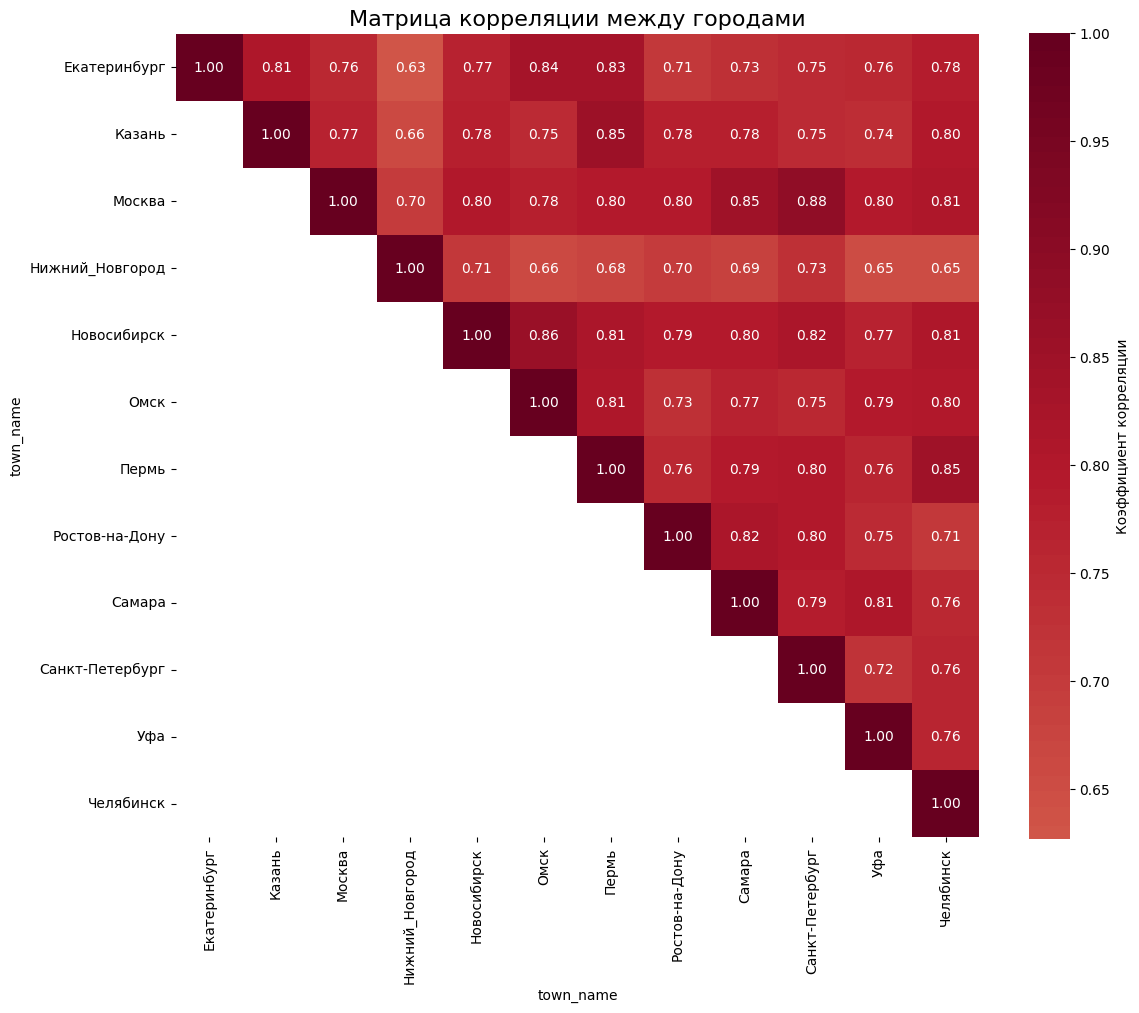

In [ ]:
def create_correlation_heatmap(corr_matrix):
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        square=True,
        cbar_kws={'label': 'Коэффициент корреляции'}
    )
    plt.title('Матрица корреляции между городами', fontsize=16)
    plt.tight_layout()
    plt.show()

create_correlation_heatmap(correlation_results['pearson'].astype(float))

key_pairs = [
    ('Москва', 'Новосибирск'),
    ('Москва', 'Екатеринбург'),
    ('Санкт-Петербург', 'Казань'),
    ('Новосибирск', 'Омск')
]